In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Single Model

## Undersampling

avalia qual metodo de undersamplig teve o melhor resultado

### r2

In [9]:
r2 = pd.read_json("../models/single_model/tables/r2_score.jsonl",
             lines=True,
             orient="records")
r2['timestamp'] = pd.to_datetime(r2['timestamp']).dt.floor('min')
r2.set_index("timestamp", inplace=True)
r2.sort_values(by=['score'], inplace=True)
r2.fillna({'undersampling':'NA'}, inplace=True)

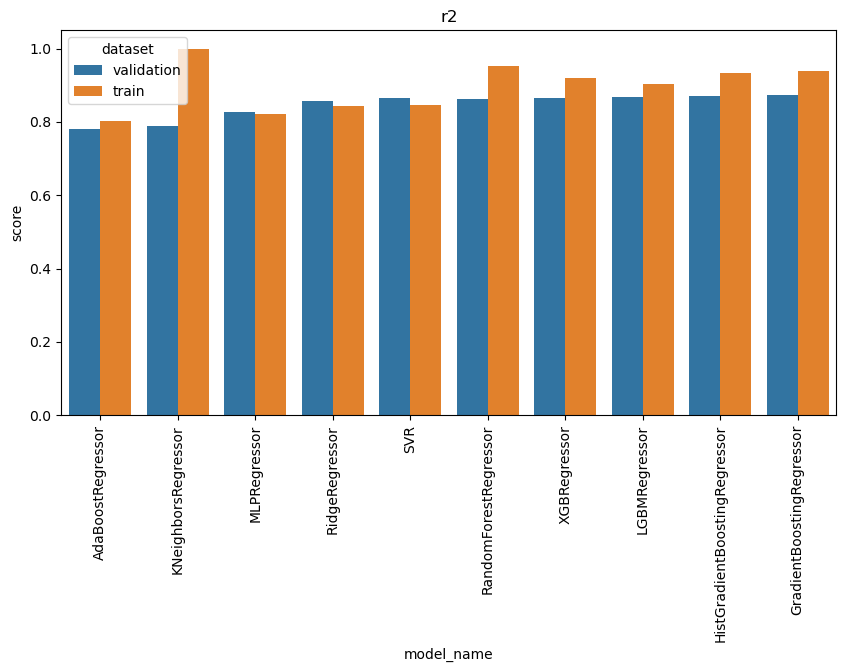

In [10]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=r2.sort_values(by='score'),
    x='model_name',
    y='score',
    hue='dataset'    
)
plt.title(f'{"r2"}')
plt.xticks(rotation=90)
plt.show()

### Mean Absolute error

In [11]:
mae = pd.read_json("../models/single_model/tables/mean_absolute_error.jsonl",
             lines=True,
             orient="records")
mae['timestamp'] = pd.to_datetime(mae['timestamp']).dt.floor('min')
mae.set_index("timestamp", inplace=True)
mae.sort_values(by=['score'], inplace=True)
mae.fillna({'undersampling':'NA'}, inplace=True)

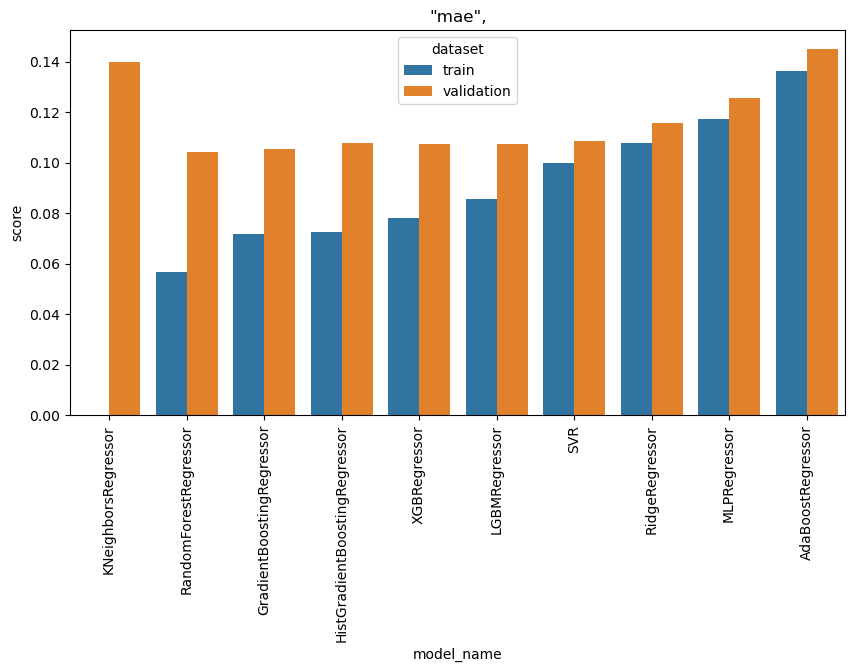

In [12]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=mae,
    x='model_name',
    y='score',
    hue='dataset'    
)
plt.title(f'"mae",')
plt.xticks(rotation=90)
plt.show()

### MSE

In [13]:
mse = pd.read_json("../models/single_model/tables/mean_squared_error.jsonl",
             lines=True,
             orient="records")
mse['timestamp'] = pd.to_datetime(mse['timestamp']).dt.floor('min')
mse.set_index("timestamp", inplace=True)
mse.sort_values(by=['score'], inplace=True)
mse.fillna({'undersampling':'NA'}, inplace=True)

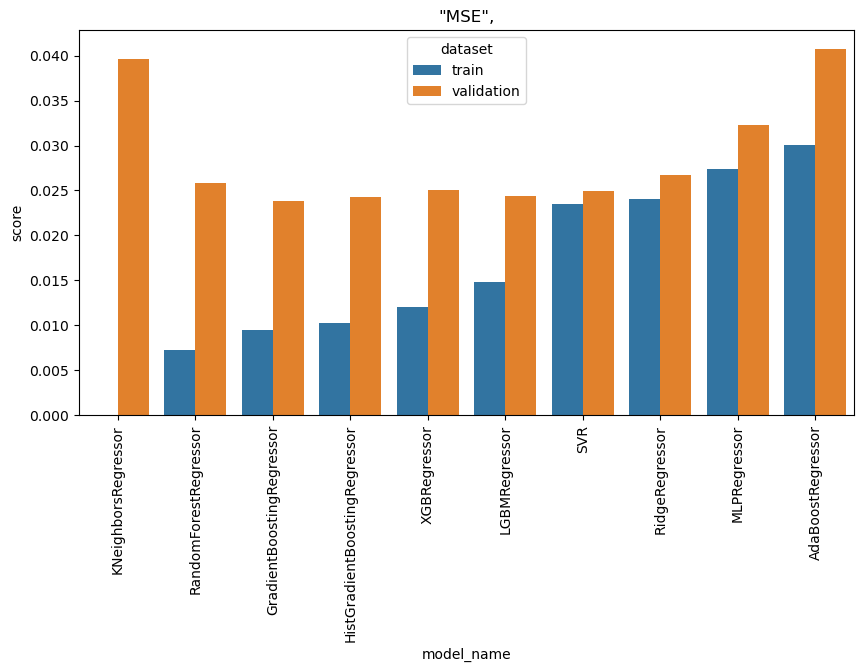

In [14]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=mse,
    x='model_name',
    y='score',
    hue='dataset'    
)
plt.title(f'"MSE",')
plt.xticks(rotation=90)
plt.show()

# ANN

In [5]:
acc_ann = pd.read_json("../models/ann_model/tables/accuracy_score.jsonl",
             lines=True,
             orient="records")
acc_ann['timestamp'] = pd.to_datetime(acc_ann['timestamp']).dt.floor('min')
acc_ann.set_index("timestamp", inplace=True)
# acc_ann.sort_values(by=['score'], inplace=True)

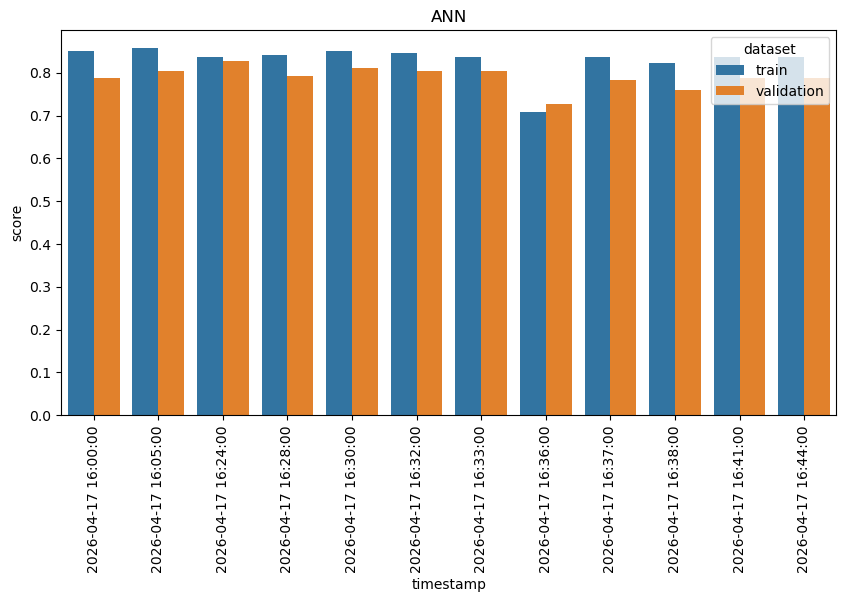

In [6]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=acc_ann,
    x='timestamp',
    y='score',
    hue='dataset'   
)
plt.title('ANN')
plt.xticks(rotation=90)
plt.show()

In [ ]:
clfrpt_ann = pd.read_json("../models/ann_model/tables/classification_report.jsonl",
             lines=True,
             orient="records")
clfrpt_ann['timestamp'] = pd.to_datetime(clfrpt_ann['timestamp']).dt.floor('min')
tmp=pd.json_normalize(clfrpt_ann['report'])
clfrpt_ann = pd.concat([clfrpt_ann, tmp], axis=1)
clfrpt_ann.drop(columns=['report'], inplace=True)

In [ ]:
plt.figure(figsize=(10,5))
sns.pointplot(
    data=clfrpt_ann,
    x='timestamp',
    y='1.f1-score',
    legend=True,
    label=1,

)
sns.pointplot(
    data=clfrpt_ann,
    x='timestamp',
    y='0.f1-score',
    legend=True,
    label=0,

)

plt.xticks(rotation=90)
plt.show()

# Voting Model

In [12]:
acc_v = pd.read_json("../models/voting_model/tables/accuracy_score.jsonl",
             lines=True,
             orient="records")
# acc_v['timestamp'] = pd.to_datetime(acc_v['timestamp']).dt.floor('min')
# acc_v.set_index("timestamp", inplace=True)

In [13]:
acc_v

,model_name,dataset,metric_name,score,undersampling,timestamp
0,voting_model,train,accuracy_score,0.852528,None,2026-03-12 17:27:13.369378
1,voting_model,validation,accuracy_score,0.804469,None,2026-03-12 17:27:13.385923
2,voting_model,train,accuracy_score,0.846910,None,2026-04-16 14:20:29.809609
3,voting_model,validation,accuracy_score,0.787709,None,2026-04-16 14:20:29.811608
4,voting_model,train,accuracy_score,0.846910,None,2026-04-20 09:00:41.749727
5,voting_model,validation,accuracy_score,0.787709,None,2026-04-20 09:00:41.752727
6,voting_model,train,accuracy_score,0.846910,None,2026-04-20 09:06:32.649520
7,voting_model,validation,accuracy_score,0.787709,None,2026-04-20 09:06:32.651522
8,voting_model,train,accuracy_score,0.846910,None,2026-04-20 09:11:22.717486
9,voting_model,validation,accuracy_score,0.787709,None,2026-04-20 09:11:22.718485


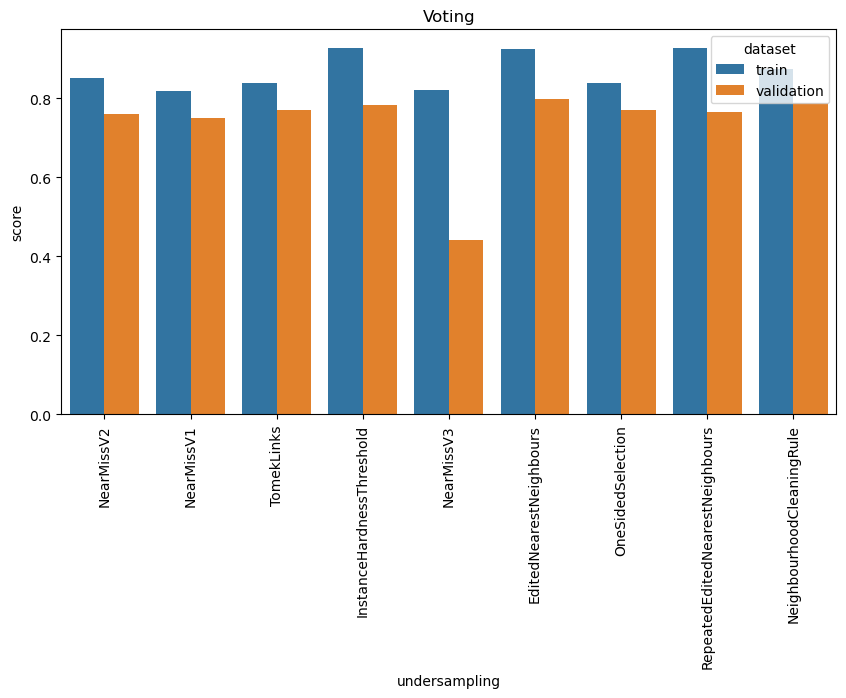

In [14]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=acc_v,
    x='undersampling',
    y='score',
    hue='dataset'   
)
plt.title('Voting')
plt.xticks(rotation=90)
plt.show()